In [ ]:
# Recharger le meilleur modèle avant évaluation
model.load_state_dict(torch.load("resnet50_best.pth", map_location=device, weights_only=True))
model.eval()
print(f"Best model rechargé depuis "resnet50_best.pth"")

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])


In [2]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:

# -------------------------
# Fonctions d'évaluation
# -------------------------

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            y_pred.append(probs.argmax(dim=1).cpu().numpy())
            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_proba),
    )


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [4]:

# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# Amélioration 2 : augmentation plus forte
# Amélioration 3 : résolution 256→crop 224
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y


train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle ResNet50 — Amélioration 1
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Amélioration 1 : fine-tuning progressif
# backbone (layer1-4) : lr faible  |  tête fc : lr plus élevé
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 6236 | Val : 780 | Test : 780


In [5]:

# Amélioration 1 : fine-tuning progressif (cohérent avec cell 7)
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "resnet50_best.pth")

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break


Epoch 01 | train loss 1.0427 train acc 0.6018 | val loss 0.7419 val acc 0.7000 | lr 1.00e-05 
Epoch 02 | train loss 0.6271 train acc 0.7441 | val loss 0.5751 val acc 0.7410 | lr 1.00e-05 
Epoch 03 | train loss 0.5268 train acc 0.7830 | val loss 0.5185 val acc 0.7821 | lr 1.00e-05 
Epoch 04 | train loss 0.4684 train acc 0.8050 | val loss 0.4829 val acc 0.7897 | lr 1.00e-05 
Epoch 05 | train loss 0.4275 train acc 0.8183 | val loss 0.4556 val acc 0.8141 | lr 1.00e-05 
Epoch 06 | train loss 0.3971 train acc 0.8326 | val loss 0.4432 val acc 0.7897 | lr 1.00e-05 
Epoch 07 | train loss 0.3742 train acc 0.8456 | val loss 0.4355 val acc 0.7897 | lr 1.00e-05 
Epoch 08 | train loss 0.3442 train acc 0.8570 | val loss 0.4238 val acc 0.8244 | lr 1.00e-05 
Epoch 09 | train loss 0.3280 train acc 0.8603 | val loss 0.4264 val acc 0.7987 | lr 1.00e-05 
Epoch 10 | train loss 0.3068 train acc 0.8708 | val loss 0.4192 val acc 0.8231 | lr 1.00e-05 
Epoch 11 | train loss 0.2876 train acc 0.8817 | val loss 0.4


=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            159              0         2            34
True_glaucome             0            186         1             8
True_mda                  2              0       187             6
True_normaux             51             10         7           127


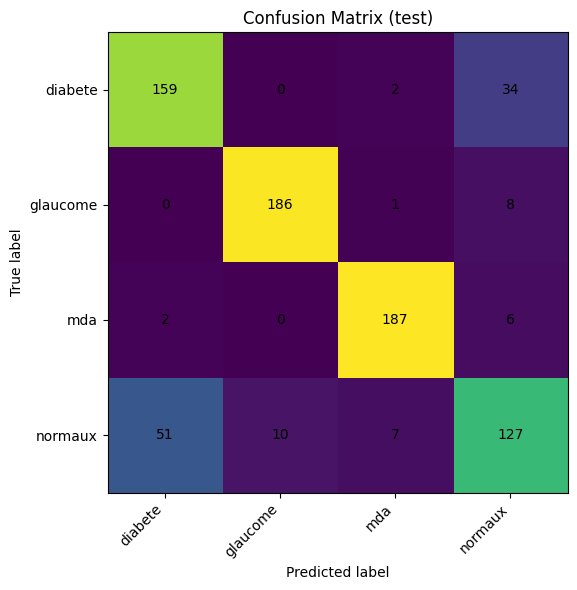


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7500    0.8154    0.7813       195
    glaucome     0.9490    0.9538    0.9514       195
         mda     0.9492    0.9590    0.9541       195
     normaux     0.7257    0.6513    0.6865       195

    accuracy                         0.8449       780
   macro avg     0.8435    0.8449    0.8433       780
weighted avg     0.8435    0.8449    0.8433       780



In [6]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))
